In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

**Словарь признаков** (имена столбцов как в `train.csv`)

* **Survived** — выжил: 0 = нет, 1 = да
* **Pclass** — класс билета: 1, 2, 3
* **Name** — имя
* **Sex** — пол
* **Age** — возраст в годах
* **SibSp** — братья/сёстры и супруги на борту
* **Parch** — родители и дети на борту
* **Ticket** — номер билета
* **Fare** — стоимость билета
* **Cabin** — номер каюты
* **Embarked** — порт посадки: C = Cherbourg, Q = Queenstown, S = Southampton

In [72]:
# Сырые данные; PassengerId — только идентификатор, для анализа не нужен
data = pd.read_csv('data/raw/train.csv')
data.drop(columns=['PassengerId'], inplace=True)
print(data.shape)
data.head()

(891, 11)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
# Пропуски есть в Age, Cabin и Embarked — это учтём при обработке
data.info()
data.isnull().sum()

Мужчин на борту больше. Смотрим, как пол связан с выживаемостью.

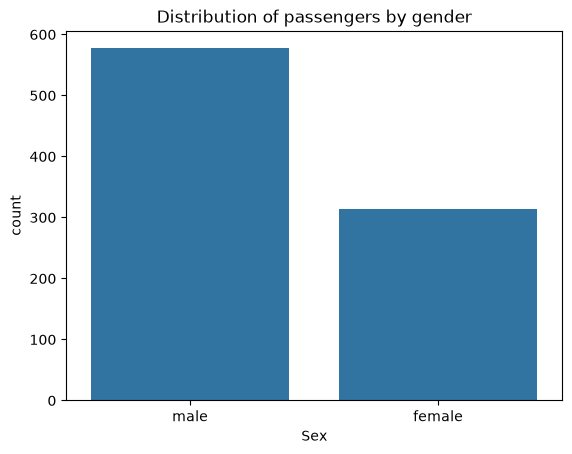

In [83]:
sns.countplot(x='Sex', data=data)
plt.title('Distribution of passengers by gender')
plt.show()

In [74]:
data.groupby(['Sex', 'Survived'])['Sex'].count()

Sex     Survived
female  0            81
        1           233
male    0           468
        1           109
Name: Sex, dtype: int64

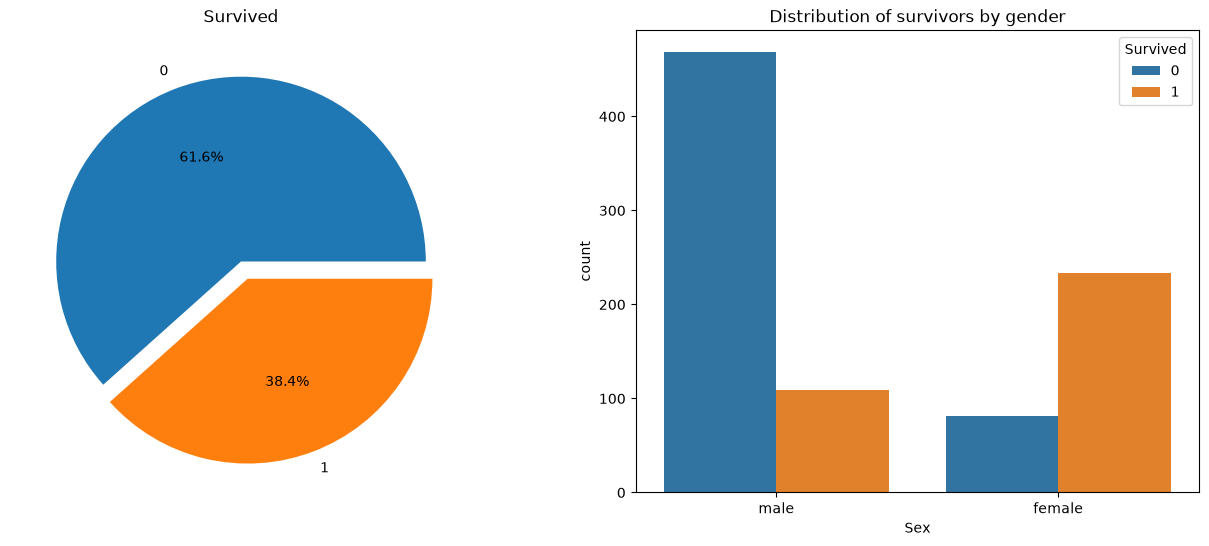

In [87]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
data['Survived'].value_counts().plot.pie(explode=[0, 0.1], autopct='%1.1f%%', ax=ax[0])
ax[0].set_title('Survived')
sns.countplot(data=data, x='Sex', hue='Survived', ax=ax[1])
ax[1].set_title('Distribution of survivors by gender')
plt.show()

Большинство ехали 3 классом. Проверяем, зависит ли выживаемость от класса билета.

In [25]:
data['Pclass'].value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
data['Pclass'].value_counts().sort_index().plot.pie(
    explode=[0.05, 0.05, 0.05], autopct='%1.1f%%', ax=ax[0]
)
ax[0].set_title('Share of passengers by class')
sns.countplot(data=data, x='Pclass', hue='Survived', ax=ax[1])
ax[1].set_title('Survival by passenger class')
plt.show()

pd.crosstab(data['Pclass'], data['Survived'], normalize='index').round(3)

<Axes: xlabel='Age', ylabel='Density'>

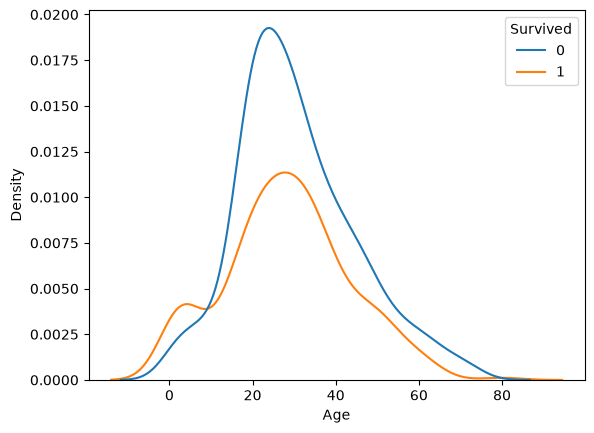

In [ ]:
sns.kdeplot(data=data, x='Age', hue='Survived')

**Коротко.** Женщины и пассажиры 1–2 класса выживали чаще. Мужчин и 3 класс — наоборот, среди них доля погибших выше. У `Age` много пропусков, их нужно будет заполнить на этапе обработки.